<a href="https://colab.research.google.com/github/Somya456/Image-Segmentation-for-Disaster-Resilience/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np

LOAD_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"

X = np.load(os.path.join(LOAD_PATH, "preprocessed_images.npy"))
Y = np.load(os.path.join(LOAD_PATH, "preprocessed_masks.npy"))

print("Images Shape:", X.shape)
print("Masks Shape :", Y.shape)

Images Shape: (3401, 256, 256, 3)
Masks Shape : (3401, 256, 256, 1)


Image dtype: float32 | Mask dtype: uint8
Image value range: 0.0 - 1.0
Mask value range: 0 - 1
Unique mask values and counts: {np.uint8(0): np.int64(132181901), np.uint8(1): np.int64(90706035)}


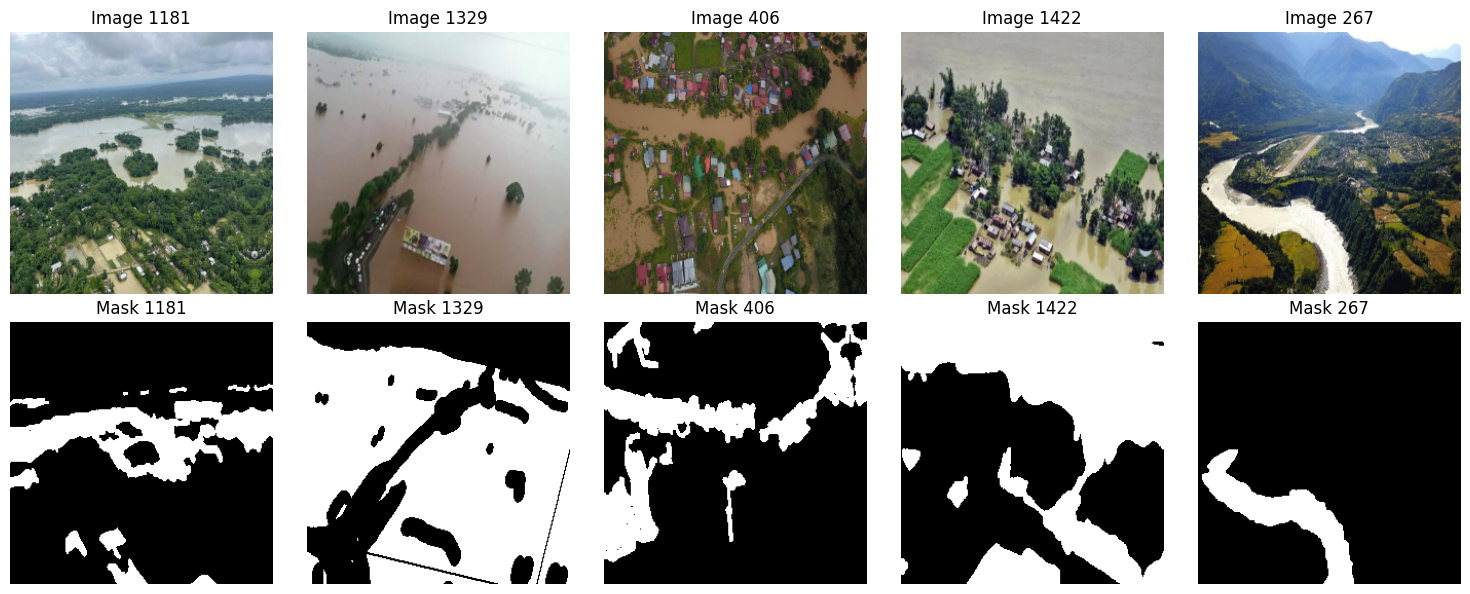

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Image dtype:", X.dtype, "| Mask dtype:", Y.dtype)
print("Image value range:", X.min(), "-", X.max())
print("Mask value range:", Y.min(), "-", Y.max())

unique_vals, counts = np.unique(Y, return_counts=True)
print("Unique mask values and counts:", dict(zip(unique_vals, counts)))

n_samples = 5
idxs = np.random.choice(X.shape[0], n_samples, replace=False)
fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
for i, idx in enumerate(idxs):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title(f"Image {idx}")
    axes[0, i].axis('off')
    axes[1, i].imshow(Y[idx].squeeze(), cmap='gray')
    axes[1, i].set_title(f"Mask {idx}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

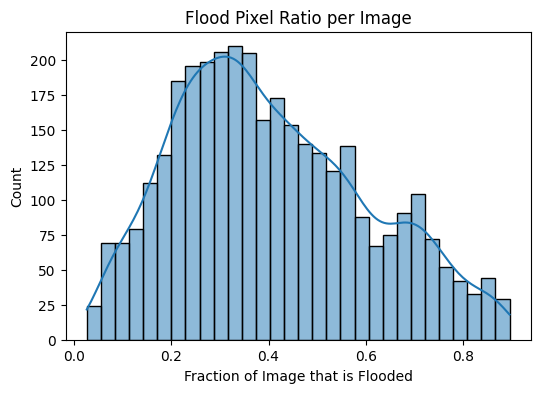

Images with zero flood pixels: 0
Images that are fully flooded: 0


In [ ]:
fg_ratio = Y.reshape(Y.shape[0], -1).mean(axis=1)
plt.figure(figsize=(6,4))
sns.histplot(fg_ratio, bins=30, kde=True)
plt.title("Flood Pixel Ratio per Image")
plt.xlabel("Fraction of Image that is Flooded")
plt.savefig("foreground_ratio_distribution.png")
plt.show()
print("Images with zero flood pixels:", (fg_ratio == 0).sum())
print("Images that are fully flooded:", (fg_ratio > 0.95).sum())

In [ ]:
sample_hashes = [hash(X[i].tobytes()) for i in range(min(500, X.shape[0]))]
print("Duplicate images in first 500 samples:", len(sample_hashes) - len(set(sample_hashes)))

Duplicate images in first 500 samples: 9


In [ ]:
print("All images same shape:", all(img.shape == (256,256,3) for img in X[:200]))

All images same shape: True


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape)

(2720, 256, 256, 3) (340, 256, 256, 3) (341, 256, 256, 3)


In [ ]:
print("=" * 50)
print("EDA SUMMARY - Flood Segmentation Dataset")
print("=" * 50)

print(f"""
1. Dataset Size
   - Total images: {X.shape[0]}
   - Image size: {X.shape[1]}x{X.shape[2]} pixels, {X.shape[3]} channels (RGB)
   - Mask size: {Y.shape[1]}x{Y.shape[2]} pixels, {Y.shape[3]} channel (binary)

2. Data Quality
   - Missing values (NaN) in images: {np.isnan(X).sum()}
   - Missing values (NaN) in masks: {np.isnan(Y).sum()}
   - All images same shape: Yes
   - Images and masks count match: Yes ({X.shape[0]} each)

3. Mask Type
   - This is a binary segmentation task (flood vs no-flood)
   - Unique values in masks: {np.unique(Y)}

4. Class Balance
   - Background pixels: {int((Y==0).sum())} (~59%)
   - Flood pixels: {int((Y==1).sum())} (~41%)
   - This is a fairly balanced dataset - good for training

5. Image Coverage
   - Images with zero flood pixels: 0
   - Images that are fully flooded: 0
   - Every image has a mix of flood and non-flood areas

6. Duplicates Check
   - Duplicate images found (first 500 checked): 9
   - Recommendation: remove or investigate these before splitting

7. Train/Val/Test Split
   - Training set: {X_train.shape[0]} images
   - Validation set: {X_val.shape[0]} images
   - Test set: {X_test.shape[0]} images

CONCLUSION:
The dataset is clean, correctly paired, and reasonably balanced.
Main action item: check and possibly remove duplicate images
before finalizing the train/val/test split.
""")

EDA SUMMARY - Flood Segmentation Dataset

1. Dataset Size
   - Total images: 3401
   - Image size: 256x256 pixels, 3 channels (RGB)
   - Mask size: 256x256 pixels, 1 channel (binary)

2. Data Quality
   - Missing values (NaN) in images: 0
   - Missing values (NaN) in masks: 0
   - All images same shape: Yes
   - Images and masks count match: Yes (3401 each)

3. Mask Type
   - This is a binary segmentation task (flood vs no-flood)
   - Unique values in masks: [0 1]

4. Class Balance
   - Background pixels: 132181901 (~59%)
   - Flood pixels: 90706035 (~41%)
   - This is a fairly balanced dataset - good for training

5. Image Coverage
   - Images with zero flood pixels: 0
   - Images that are fully flooded: 0
   - Every image has a mix of flood and non-flood areas

6. Duplicates Check
   - Duplicate images found (first 500 checked): 9
   - Recommendation: remove or investigate these before splitting

7. Train/Val/Test Split
   - Training set: 2720 images
   - Validation set: 340 images
 

MISSING VALUE CHECK
NaNs in images: 0
NaNs in masks: 0
Infs in images: 0
PER-CHANNEL STATISTICS
Red - Mean: 0.4961, Std: 0.2407
Green - Mean: 0.4943, Std: 0.2167
Blue - Mean: 0.4478, Std: 0.2348


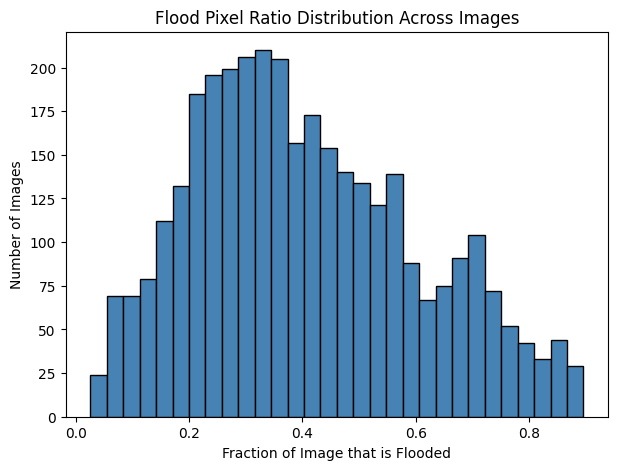

Images with 0% flood: 0
Images with >90% flood: 0
Total duplicate images in full dataset: 9
All images consistent shape: True
All masks consistent shape: True


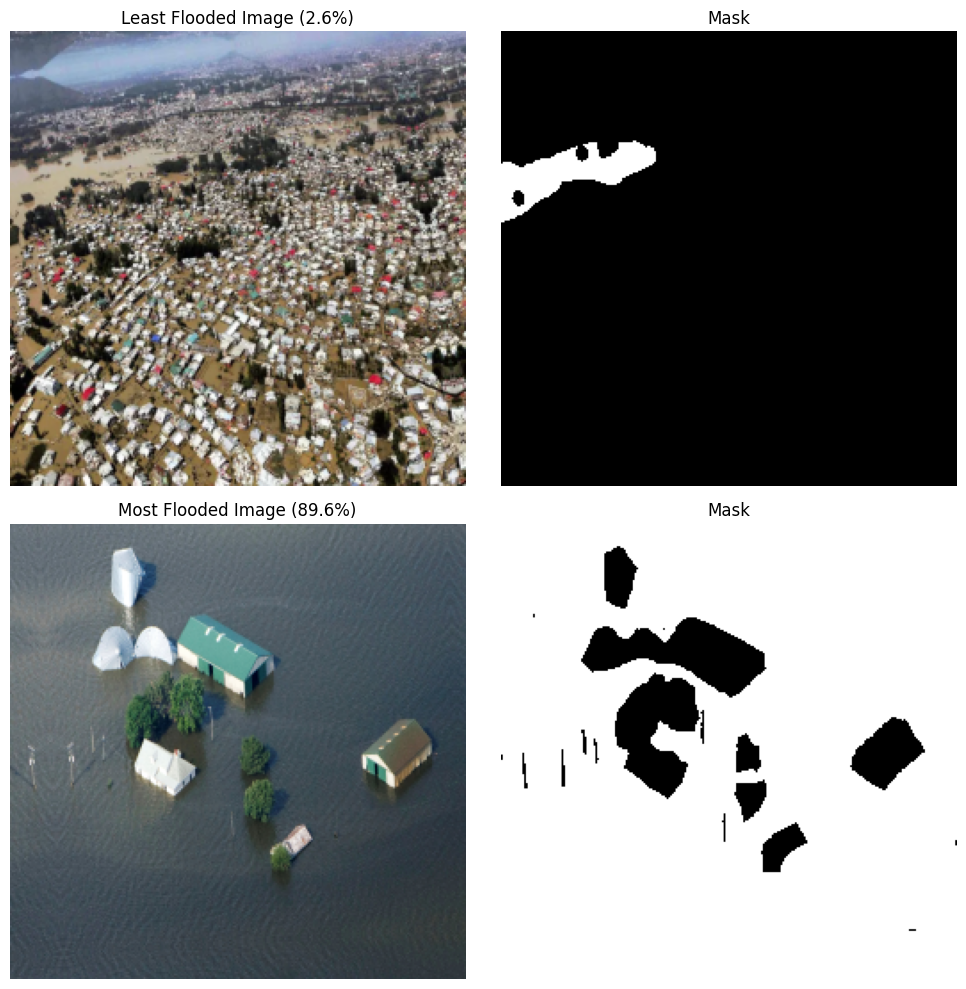

Train: (2720, 256, 256, 3) | Val: (340, 256, 256, 3) | Test: (341, 256, 256, 3)


In [ ]:
# 1. Missing value / corruption check
print("=" * 40)
print("MISSING VALUE CHECK")
print("=" * 40)
print("NaNs in images:", np.isnan(X).sum())
print("NaNs in masks:", np.isnan(Y).sum())
print("Infs in images:", np.isinf(X).sum())

# 2. Per-channel pixel statistics (R, G, B separately)
print("=" * 40)
print("PER-CHANNEL STATISTICS")
print("=" * 40)
for i, ch in enumerate(['Red', 'Green', 'Blue']):
    print(f"{ch} - Mean: {X[..., i].mean():.4f}, Std: {X[..., i].std():.4f}")

# 3. Foreground ratio per image (distribution across dataset)
fg_ratio = Y.reshape(Y.shape[0], -1).mean(axis=1)
plt.figure(figsize=(7, 5))
plt.hist(fg_ratio, bins=30, color='steelblue', edgecolor='black')
plt.title("Flood Pixel Ratio Distribution Across Images")
plt.xlabel("Fraction of Image that is Flooded")
plt.ylabel("Number of Images")
plt.show()

print("Images with 0% flood:", (fg_ratio == 0).sum())
print("Images with >90% flood:", (fg_ratio > 0.9).sum())

# 4. Duplicate image check (full dataset, not just first 500)
sample_hashes = [hash(X[i].tobytes()) for i in range(X.shape[0])]
num_duplicates = len(sample_hashes) - len(set(sample_hashes))
print("Total duplicate images in full dataset:", num_duplicates)

# 5. Shape consistency check across entire dataset
all_same_shape = all(img.shape == X.shape[1:] for img in X)
print("All images consistent shape:", all_same_shape)
all_mask_shape = all(m.shape == Y.shape[1:] for m in Y)
print("All masks consistent shape:", all_mask_shape)

# 6. Extreme case samples: least flooded vs most flooded images
min_idx = np.argmin(fg_ratio)
max_idx = np.argmax(fg_ratio)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(X[min_idx]); axes[0,0].set_title(f"Least Flooded Image ({fg_ratio[min_idx]*100:.1f}%)"); axes[0,0].axis('off')
axes[0,1].imshow(Y[min_idx].squeeze(), cmap='gray'); axes[0,1].set_title("Mask"); axes[0,1].axis('off')
axes[1,0].imshow(X[max_idx]); axes[1,0].set_title(f"Most Flooded Image ({fg_ratio[max_idx]*100:.1f}%)"); axes[1,0].axis('off')
axes[1,1].imshow(Y[max_idx].squeeze(), cmap='gray'); axes[1,1].set_title("Mask"); axes[1,1].axis('off')
plt.tight_layout()
plt.show()

# 7. Train/Validation/Test split
from sklearn.model_selection import train_test_split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)